## **引言**
为使语言模型有益、诚实、无害，本文使用人类反馈强化学习（RLHF）对GPT-3模型进行微调。

#### 具体做法
用人类标注的数据集训练一个奖励模型，并使用PPO算法来微调语言模型

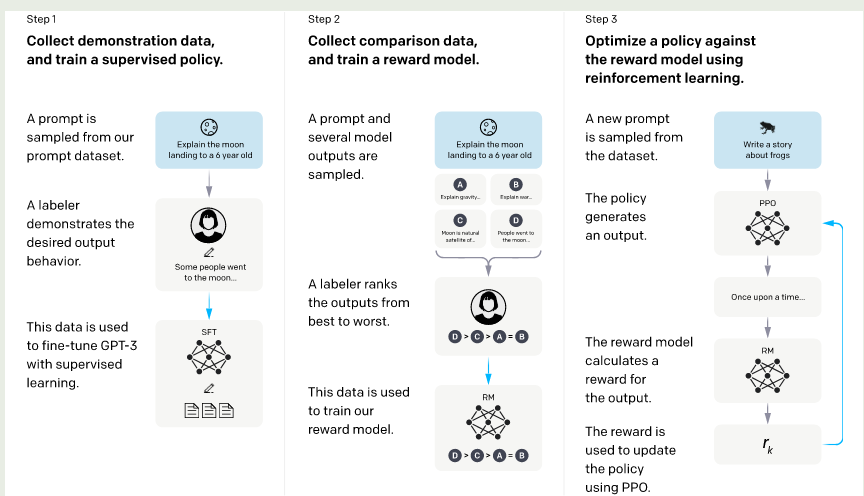

#### **步骤一：监督微调（Supervised Fine-Tuning, SFT）**

*   **目标：** 让预训练语言模型（Pre-trained Language Model, PLM）适应指令遵循（instruction-following）的格式和风格。PLM 原始目标是预测下一个词，但并不一定能很好地理解和执行用户指令。SFT 阶段就是为了弥补这个差距。
*   **流程：**
    1.  **数据收集：** 从一个广泛的来源（例如用户提交的真实查询或由人工设计的查询）采样得到一个提示（prompt）数据集 $D_{prompts}$。
    2.  **人工标注：** 雇佣专业的标注员为每个提示 $x \in D_{prompts}$ 编写一个高质量的、示范性的回答 $y^*$。
    3.  **数据集构建：** 将提示和示范回答组合成一个监督学习数据集 $D_{SFT} = \{(x_i, y_i^*)\}_{i=1}^N$。
    4.  **模型训练：** 使用这个数据集对一个预训练语言模型（例如 GPT-3）进行微调。本质上，这是一个标准的自回归语言建模任务。

*   **数学模型：**
    训练的目标是最大化给定提示 $x$ 时，模型生成示范回答 $y^*$ 的条件概率。这通过最小化负对数似然损失（Negative Log-Likelihood Loss）来实现。假设模型参数为 $\theta$，SFT 阶段的损失函数 $L_{SFT}$ 为：
    $$
    L_{SFT}(\theta) = -\sum_{(x, y^*) \in D_{SFT}} \log P_\theta(y^*|x)
    $$
    其中 $P_\theta(y^*|x)$ 是模型在给定提示 $x$ 的情况下，生成序列 $y^*$ 的概率。通常，这会被分解为每个 token 的条件概率之积：
    $$
    \log P_\theta(y^*|x) = \sum_{t=1}^{|y^*|} \log P_\theta(y_t^* | x, y_{<t}^*)
    $$
    这个阶段完成后，我们得到一个 SFT 模型，记为 $\pi_{SFT}$。它已经具备了初步的指令遵循能力。

#### **步骤二：训练奖励模型（Reward Model, RM）**

*   **目标：** 训练一个能够模拟人类偏好的模型，使其可以对任意（提示，回答）对 $(x, y)$ 给出一个标量分数 $r$，分数越高表示人类越偏爱这个回答。
*   **流程：**
    1.  **数据收集：** 从提示数据集中采样一个提示 $x$。
    2.  **生成多个回答：** 使用 SFT 模型 $\pi_{SFT}$ 对同一个提示 $x$ 生成 $K$ 个不同的回答 $\{y_1, y_2, \dots, y_K\}$。（例如，通过调整 temperature 参数）。
    3.  **人工排序：** 标注员对这 $K$ 个回答进行排序，从最好到最差。例如，对于图片中的4个回答 A, B, C, D，标注员给出的排序是 $D \succ C \succ A \approx B$（$\succ$ 表示“优于”）。
    4.  **数据集构建：** 将排序结果转化为成对的比较数据。一个包含 $K$ 个回答的排序可以生成 $\binom{K}{2}$ 个比较对。例如，从 $D \succ C \succ A$ 可以得到 $(y_D, y_C)$, $(y_D, y_A)$, $(y_C, y_A)$ 三个偏好对。我们构建一个包含大量偏好对 $(y_w, y_l)$ 的数据集 $D_{RM}$，其中 $y_w$ 是被偏好的回答（winner），$y_l$ 是不被偏好的回答（loser），两者都对应同一个提示 $x$。

*   **数学模型：**
    奖励模型 $r_\phi(x, y)$ 是一个以模型参数 $\phi$ 为参数的函数（通常也是一个 Transformer 模型），输入为 $(x, y)$，输出为一个标量得分。我们希望对于任意一个偏好对 $(y_w, y_l)$，RM 的打分满足 $r_\phi(x, y_w) > r_\phi(x, y_l)$。
    训练 RM 的损失函数通常基于 Bradley-Terry 模型，该模型将成对比较的概率与潜在的得分联系起来。损失函数 $L_{RM}$ 如下：
    $$
    L_{RM}(\phi) = -\mathbb{E}_{(x, y_w, y_l) \sim D_{RM}} \left[ \log\left(\sigma\left(r_\phi(x, y_w) - r_\phi(x, y_l)\right)\right) \right]
    $$
    其中：
    *   $\sigma(z) = 1 / (1 + e^{-z})$ 是 Sigmoid 函数。
    *   $r_\phi(x, y_w) - r_\phi(x, y_l)$ 是两个回答的得分差。
    *   整个表达式的目标是最大化 RM 赋予 $y_w$ 的得分高于 $y_l$ 的概率。通过最小化这个负对数似然损失，我们训练出奖励模型 $r_\phi$。

#### **步骤三：基于 PPO 的强化学习优化**

*   **目标：** 利用奖励模型 $r_\phi$ 作为环境回馈，进一步优化 SFT 模型，使其生成的回答能获得更高的奖励分数，从而更好地与人类偏好对齐。
*   **流程：**
    1.  **初始化策略：** 将 SFT 模型 $\pi_{SFT}$ 作为初始策略，我们称当前正在优化的策略为 $\pi_{RL}^\theta$。
    2.  **环境交互：** 从一个提示数据集 $D_{RL}$ 中采样一个提示 $x$。
    3.  **生成回答（Action）：** 当前策略 $\pi_{RL}^\theta$ 根据提示 $x$ 生成一个回答 $y$。在 RL 语境中，提示 $x$ 是“状态（State）”，生成的回答 $y$（或者说生成回答的每个词）是“动作（Action）”。
    4.  **计算奖励（Reward）：** 将 $(x, y)$ 输入到第二步训练好的奖励模型 $r_\phi$ 中，得到一个标量奖励 $r = r_\phi(x, y)$。
    5.  **策略更新：** 使用 PPO 算法，根据这个奖励信号来更新策略模型 $\pi_{RL}^\theta$ 的参数 $\theta$。这个过程是迭代进行的，不断采样、生成、评分、更新。

*   **数学模型：**
    直接最大化奖励 $\mathbb{E}_{y \sim \pi_{RL}^\theta(\cdot|x)}[r_\phi(x, y)]$ 会导致一个问题：模型可能会学会生成一些虽然能得到高分但语言上乱七八糟的“咒语”来“欺骗”奖励模型（即 **Reward Hacking**），并且可能丧失其在预训练和SFT阶段学到的语言能力。
    为了解决这个问题，PPO 优化目标中加入了一个惩罚项，以防止当前策略 $\pi_{RL}^\theta$ 与初始的 SFT 策略 $\pi_{SFT}$ 偏离太远。这个惩罚项通常是 **KL 散度（Kullback-Leibler Divergence）**。
    完整的优化目标如下：
    $$
    \text{objective}(\phi) = \mathbb{E}_{(x,y)\sim D_{\pi_\phi^{RL}}} [r_\theta(x, y) - \beta \log(\pi_\phi^{RL}(y|x)/\pi^{SFT}(y|x))] + \gamma \mathbb{E}_{x\sim D_{pretrain}}[\log(\pi_\phi^{RL}(x))]
    $$

    其中：
    *   $r_\phi(x,y)$ 是奖励模型给出的奖励。
    *   $\text{KL}(\pi_{RL}^\theta || \pi_{SFT})$ 计算了两个策略分布的差异。这个项作为惩罚，值越大，说明当前策略偏离初始策略越远。
    *   $\beta$ 是一个超参数，用于控制 KL 惩罚的强度。它平衡了“追求更高奖励”和“保持语言模型本真”这两个目标。
    *   最后一项是一个可选的附加项，也是区分PPO和PPO-ptx模型的关键。它将原始预训练数据集 $D_{pretrain}$ （预训练GPT-3模型的数据）中的样本拿过来，要求模型在这些通用文本上仍然能保持较高的生成概率（即最大化对数似然）。$\gamma$ 是控制这个附加项强度的系数。
    
        因为对齐过程（SFT和RLHF）可能会让模型在遵循指令方面表现出色，但在一些通用的、预训练时学会的能力上（如知识问答、代码补全）发生性能衰退。这个附加项通过“温习”预训练知识，来抵抗这种性能衰退。

#### 步骤二和步骤三可以持续迭代，在当前最佳策略上收集比较数据，用于训练新的奖励模型，然后得到新的策略

## **方法与实验细节**
#### 雇佣标注员来创建高质量的初始指令数据集
#### **设计指令来源——三类提示的构建策略**
为了确保数据集的**多样性（Diversity）**和**真实性（Authenticity）**，研究团队设计了三种指令生成方式：
1.  **Plain Prompts (简单指令):**
    *   **定义：** “我们只需要求标注者随意想出一个任务，同时确保任务具有足够的多样性。”
    *   **目的：** 这是为了广泛覆盖各种可能的指令类型，避免数据类型过于单一。例如，可以包含开放式生成（写一首诗）、改写（把这段话改得更正式）、分类（判断这句话的情感）、提取信息等各种任务。这是保证模型泛化能力的基础。

2.  **Few-shot Prompts (少样本指令):**
    *   **定义：** “我们要求标注者编辑一个指令，以及该指令的多个查询/响应对。”
    *   **目的：** 这类指令旨在教会模型处理“上下文学习（In-context Learning）”的场景。用户给出指令的同时，也提供了一些范例。模型需要先理解这些范例，然后在新查询上应用相同的模式。这大大增强了模型处理复杂和特定格式要求任务的能力。

3.  **User-based Prompts (基于用户的指令):**
    *   **定义：** “我们在向OpenAI API提交的候补申请中提出了许多用例。我们要求标注者提出与这些用例对应的提示。”
    *   **目的：** 这是确保模型“有用性”的关键一环。通过将真实用户（开发者）希望用API解决的问题转化为训练指令，模型可以直接学习满足市场需求的技能。这建立了一个从真实需求到模型能力的直接通路。

#### **模型**
1.  **SFT**
    *   用得到的数据去监督微调一个预训练模型（GPT-3），这训练了16个epoch，尽管一个epoch就会使模型过拟合（验证集上的损失上升），但是继续训练下去，得到的模型在奖励模型看来分数会上升，并且在后续的人类偏好盲测中也更受欢迎。这可能因为，传统的交叉熵损失并不能完美地衡量“与人类偏好对齐”这个最终目标。

2.  **奖励模型**
    *   让SFT后的模型对同一个问题给出多个回答。让标注员对这些回答的质量进行排序，用这些排序数据来训练一个奖励模型。RM需要给定一个问题和对应的回答，输出一个分数。
    *   RM直接复用了SFT模型，但移除了原有的用于预测下一个词的输出层，换上了一个新的、小型的线性头，这个头的输出只有一个神经元，用于产生一个标量值，即奖励分数。
    *   考虑训练稳定性和计算成本，使用了6B的模型，而不是更大的。因为RL阶段每一次生成token都需要进行一次前向传播来计算奖励。
    *   训练使用pairwise方法，通过学习大量的成对偏好关系，间接地学习到一个能够为任何单个项目打分（并以此进行排序）的函数。损失函数用logistic函数，因为RM任务可以理解成是“$y_w$ 是否比 $y_l$ 更好”，这样一个二分类问题。
        
        二分类问题损失函数：$L_{BCE} = -[y \log(p) + (1-y) \log(1-p)]$，y表示真实标签，因为这里用的都是(winner, loser)对，所以y恒等于1
    *   为防止过拟合，同一个提示词的所有比较对作为一个批次进行训练，也可以节约成本

3.  **强化学习部分**
    *   PPO-ptx  不断根据反馈来调整参数